# 11 — Unprocessed food: Bayesian AR-SV-outlier


### Economic specification (AR(1,10,12))

The economic contract follows **ECB WP 374 (2004)** for euro-area unprocessed food:

- monthly non-seasonally-adjusted HICP;
- first log difference of the HICP index;
- lags 1, 10 and 12 in the exact paper benchmark;
- 11 monthly seasonal dummies, with December as the reference month.

### Bayesian machinery (AR(12))

The production approximation uses the same validated project engine as the Energy suite, based on the modern ECB energy BVAR implementation:

- Minnesota prior centred on white noise;
- stochastic volatility;
- model-based transitory outliers;
- Durbin–Koopman handling of missing/ragged-edge observations;
- posterior HICP paths produced draw by draw.

The current production approximation is a **dense Bayesian AR(12)**. The exact sparse `AR(1,10,12)` remains visible as a benchmark. We do not silently claim that these are the same specification.

## 1. Imports and configuration

In [3]:
from __future__ import annotations

import os
import sys
from dataclasses import asdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/ and src/.")


env_root = os.environ.get("BVAR_PROJECT_ROOT")
PROJECT_ROOT = Path(env_root).expanduser().resolve() if env_root else find_project_root(Path.cwd())
MODEL_DIR = PROJECT_ROOT / "src" / "model"
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

from headline_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    forecast_headline_component,
    headline_component_contract_table,
    headline_component_spec,
    headline_forecast_horizon_table,
    headline_nowcast_summary_table,
    headline_panel_audit,
    headline_series_construction_table,
    headline_transformation_table,
    load_headline_component_panel,
    native_model_differences,
    prepare_headline_component,
    resolve_headline_component_dataset,
    run_headline_bvar,
    wp374_unprocessed_food_sparse_benchmark,
)

from headline_bvar_plot import (
    plot_headline_hicp_forecast_fan,
    plot_headline_model_differences,
    plot_headline_native_levels,
)

from energy_bvar_model import (
    coefficient_posterior_table,
    mcmc_diagnostics,
    posterior_predictive_statistics,
    residual_diagnostic_table,
    stability_diagnostics,
    stationarity_tests,
)

from energy_bvar_plot import (
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_minnesota_prior_by_equation,
    plot_outlier_probabilities,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_posterior_volatility,
    plot_shrinkage_comparison,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    style_numeric_table,
)

try:
    from energy_bvar_io import save_energy_bvar_result
except ImportError:
    save_energy_bvar_result = None

COMPONENT = "unprocessed_food"
SPEC = headline_component_spec(COMPONENT)

# None -> data/processed. During development this can point to the isolated preview root:
# DATA_ROOT = PROJECT_ROOT / "data" / "scratch" / "headline_preview"
DATA_ROOT = None
VINTAGE = None  # None = latest vintage available under DATA_ROOT.

QUICK_TEST = False
FORECAST_HORIZON = 18
FORECAST_DRAWS = 250 if QUICK_TEST else 1_000
SAVE_RESULTS = False

PRIOR_CONFIG = BVARSVOPriorConfig()  # same project defaults as the Energy suite
SAMPLER_CONFIG = SamplerConfig(
    reps=300 if QUICK_TEST else 6_000,
    burn=150 if QUICK_TEST else 3_000,
    thin=1,
    seed=42,
    progress_every=0 if QUICK_TEST else 500,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("COMPONENT:", COMPONENT)
print("Implementation:", SPEC["implementation_mode"])

PROJECT_ROOT: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
COMPONENT: unprocessed_food
Implementation: dense_bayesian_ar12_shrinkage_approximation


## 2. Model contract

In [4]:
display(headline_component_contract_table())
display(headline_transformation_table(COMPONENT))

,label,dataset_file,target,paper_model_class,paper_lag_structure,active_lags,implementation_mode,production_ready,production_blocker
component,,,,,,,,,
unprocessed_food,Unprocessed food,unprocessed_food_monthly.csv,hicp_unprocessed_food,dynamic single equation / autoregression,"HICP unprocessed food L1, L10, L12 + 11 monthl...",None,dense_bayesian_ar12_shrinkage_approximation,True,None
processed_food,Processed food,processed_food_monthly.csv,hicp_processed_food,dynamic single equation,HICP PF L1-L4; food commodities L2; wages L0-L...,"[1, 2, 3, 4]",bayesian_arx4_sv_outlier_exact_wp374_lag_struc...,True,None
neig,Non-energy industrial goods,neig_monthly.csv,hicp_neig,dynamic single equation,"HICP NEIG L1,L6,L12; PPI consumer goods L1; wa...","[1, 6, 12]",bayesian_sparse_arx12_sv_outlier_exact_wp374_l...,True,None
services,Services,services_monthly.csv,hicp_services,BVAR,Services/wages/PPI consumer goods/unprocessed ...,"[1, 2, 3, 4, 5, 12]",bayesian_sparse_bvar12_sv_outlier_exact_wp374_...,True,None


,role,native_unit,transform,state_level,model_change,state_variable,paper_active_lags
native_series,,,,,,,
hicp_unprocessed_food,target,HICP index,logdiff,log(hicp_unprocessed_food),Δlog(hicp_unprocessed_food),state__hicp_unprocessed_food,"[1, 10, 12]"


The transformation is explicit in the adapter:

```text
native HICP index
      ↓ log
state level
      ↓ first difference inside shared engine
Δ log(HICP)
```

This is deliberately different from Energy, where native and state levels are identical and the shared engine therefore estimates absolute first differences. The **mechanism** is harmonised; the economically justified transformation is not forced to be identical.

## 3. Data

In [5]:
DATASET_PATH = resolve_headline_component_dataset(
    PROJECT_ROOT,
    COMPONENT,
    vintage=VINTAGE,
    data_root=DATA_ROOT,
)
VINTAGE_USED = DATASET_PATH.parent.name

native_levels = load_headline_component_panel(DATASET_PATH, COMPONENT)

print("Dataset:", DATASET_PATH)
print("Vintage:", VINTAGE_USED)
display(headline_series_construction_table(DATASET_PATH, COMPONENT))
display(headline_panel_audit(native_levels, COMPONENT))

Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260811\unprocessed_food_monthly.csv
Vintage: 20260811


,dataset_file,role,native_unit,transform,state_level,model_change,state_variable,paper_active_lags,paper_model_class,paper_lag_structure,implementation_mode
native_series,,,,,,,,,,,
hicp_unprocessed_food,unprocessed_food_monthly.csv,target,HICP index,logdiff,log(hicp_unprocessed_food),Δlog(hicp_unprocessed_food),state__hicp_unprocessed_food,"[1, 10, 12]",dynamic single equation / autoregression,"HICP unprocessed food L1, L10, L12 + 11 monthl...",dense_bayesian_ar12_shrinkage_approximation


,role,unit,first_observed,last_observed,n_calendar,n_observed,n_missing,missing_share
series,,,,,,,,
hicp_unprocessed_food,target,HICP index,1996-01-01,2026-07-01,367,367,0,0.0


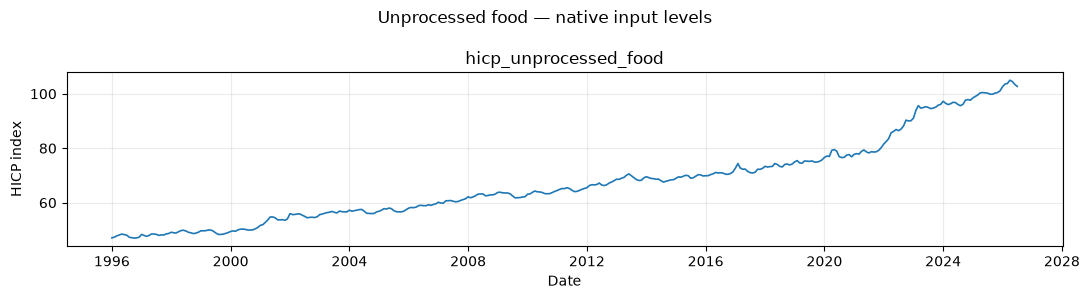

In [6]:
plot_headline_native_levels(
    native_levels,
    component_label=SPEC["label"],
    units=SPEC["units"],
)
plt.show()

### 3.1 Model-space transformation

,count,mean,std,min,25%,50%,75%,max
hicp_unprocessed_food,366.0,0.00213,0.007788,-0.025802,-0.002842,0.001918,0.006597,0.033969


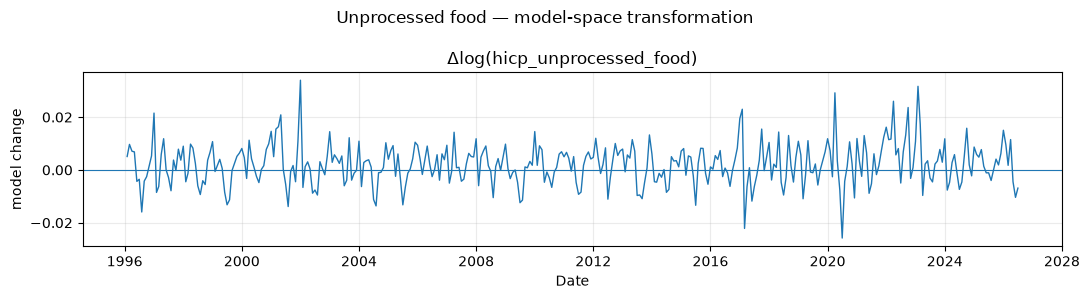

In [7]:
model_differences = native_model_differences(native_levels, COMPONENT)
transformation_table = headline_transformation_table(COMPONENT)
transform_labels = transformation_table["model_change"].to_dict()

display(model_differences.describe().T)
plot_headline_model_differences(
    model_differences,
    component_label=SPEC["label"],
    transform_labels=transform_labels,
)
plt.show()

## 4. Exact ECB WP374 sparse benchmark

This is the exact lag structure selected by the 2004 paper:

\[
\Delta\log I_t^{UF}
= c + \beta_1\Delta\log I_{t-1}^{UF}
+ \beta_{10}\Delta\log I_{t-10}^{UF}
+ \beta_{12}\Delta\log I_{t-12}^{UF}
+ \text{seasonal dummies} + u_t.
\]

It is a benchmark, not the production posterior model.

In [8]:
wp374 = wp374_unprocessed_food_sparse_benchmark(native_levels)
display(wp374["comparison"])

paper_regression = wp374["fit"].summary2().tables[1]
display(paper_regression)

print("Current benchmark sample:", wp374["data"].index.min(), "→", wp374["data"].index.max())
print("R²:", round(float(wp374["fit"].rsquared), 4))

,WP374_reported,current_sample
L1,0.2254,0.152242
L10,0.2325,0.023432
L12,-0.1670,-0.044672


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,0.004571,0.001203,3.800892,1.709055e-04,0.002206,0.006937
L1,0.152242,0.053909,2.824052,5.022531e-03,0.046204,0.258280
L10,0.023432,0.053996,0.433954,6.645979e-01,-0.082778,0.129642
L12,-0.044672,0.053495,-0.835069,4.042669e-01,-0.149895,0.060552
SD1,0.006181,0.001677,3.684767,2.663849e-04,0.002881,0.009480
SD2,-0.003070,0.001693,-1.812949,7.072408e-02,-0.006401,0.000261
SD3,-0.003707,0.001636,-2.266247,2.406621e-02,-0.006924,-0.000490
SD4,0.001210,0.001639,0.738270,4.608615e-01,-0.002014,0.004434
SD5,-0.000124,0.001725,-0.072035,9.426168e-01,-0.003516,0.003268
SD6,-0.006587,0.001729,-3.809963,1.650044e-04,-0.009988,-0.003186


Current benchmark sample: 1997-02-01 00:00:00 → 2026-07-01 00:00:00
R²: 0.3783


## 5. Bayesian prior and sampler configuration

In [9]:
display(pd.Series(asdict(PRIOR_CONFIG), name="value").to_frame())
display(pd.Series(asdict(SAMPLER_CONFIG), name="value").to_frame())

,value
lambda1,2.000000e-01
lambda2,5.000000e-01
lambda3,1.000000e+00
lambda4,1.000000e+01
a_prior_var,1.000000e+01
phi_prior_mean,2.000000e-02
phi_prior_df,1.000000e+01
h0_var,4.000000e+00
outlier_mean_frequency,2.083333e-02
outlier_prior_observations,1.200000e+02


,value
reps,6000
burn,3000
thin,1
seed,42
max_stability_tries,1000
progress_every,500
sv_sampler,centered_ksc
dk_projection_mode,strict
dk_level_relative_gate,0.000001
dk_difference_relative_gate,0.000001


For this one-variable system, `lambda2` (cross-variable shrinkage) and the prior on below-diagonal contemporaneous coefficients are mechanically inactive. They remain in the shared configuration object so that the same production interface is used across the suite.

## 6. Prepare and estimate

In [10]:
prepared = prepare_headline_component(native_levels, COMPONENT)

print("Native columns:", list(prepared["native_levels"].columns))
print("State columns:", list(prepared["state_levels"].columns))
print("Seasonal columns:", [] if prepared["exog"] is None else list(prepared["exog"].columns))

Native columns: ['hicp_unprocessed_food']
State columns: ['state__hicp_unprocessed_food']
Seasonal columns: ['month_01', 'month_02', 'month_03', 'month_04', 'month_05', 'month_06', 'month_07', 'month_08', 'month_09', 'month_10', 'month_11']


In [11]:
result = run_headline_bvar(
    prepared,
    component=COMPONENT,
    vintage=VINTAGE_USED,
    prior_config=PRIOR_CONFIG,
    sampler_config=SAMPLER_CONFIG,
    exog_prior_scale=10.0,
    code_version="headline-unprocessed-food-v1",
)

print("Run ID:", result["metadata"]["run_id"])
print("Posterior draws:", result["n_draws"])
print("Balanced end:", result["prep"]["balanced_end"])
print("DK data augmentation:", result["prep"].get("requires_data_augmentation", False))

iteration 500/6,000 | B instability rejection 0.00% | radius 0.8132
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.7968
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.7967
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.8115
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.8043
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.7723
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.7507
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.8086
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.7468
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.7609
iteration 5,500/6,000 | B instability rejection 0.00% | radius 0.7957
iteration 6,000/6,000 | B instability rejection 0.00% | radius 0.7262
Run ID: 5a34a7c3951eb37d04885ff872a5c77addb3cb2d2c296b5e0646e7f981df3173
Posterior draws: 3000
Balanced end: 2026-07-01 00:00:00
DK data augmentation: False


## 7. Prior and posterior coefficients

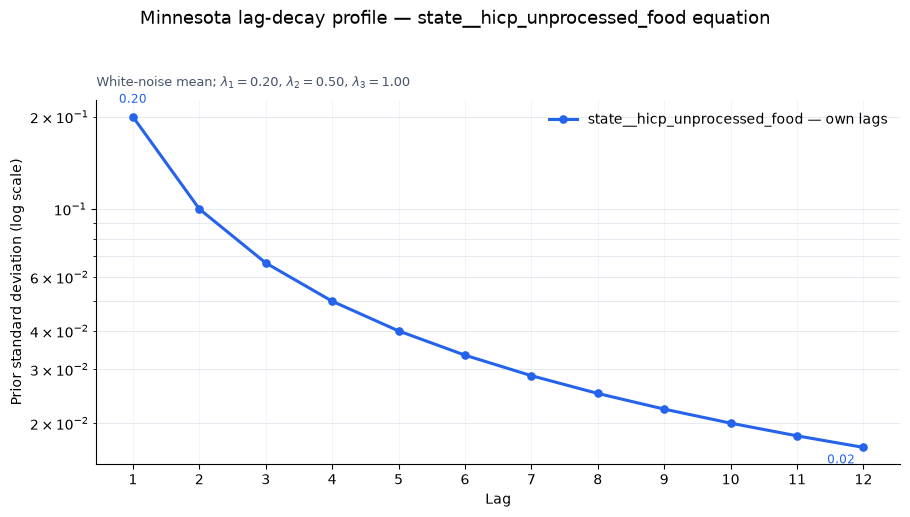

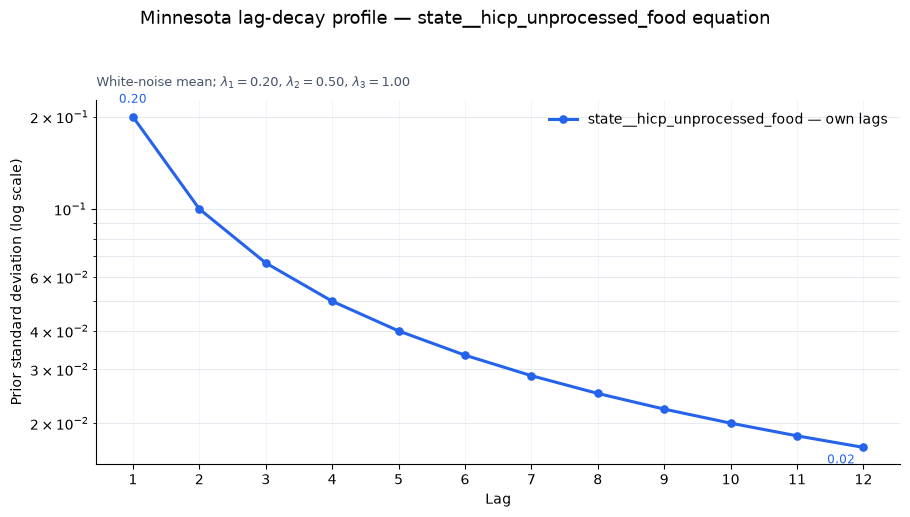

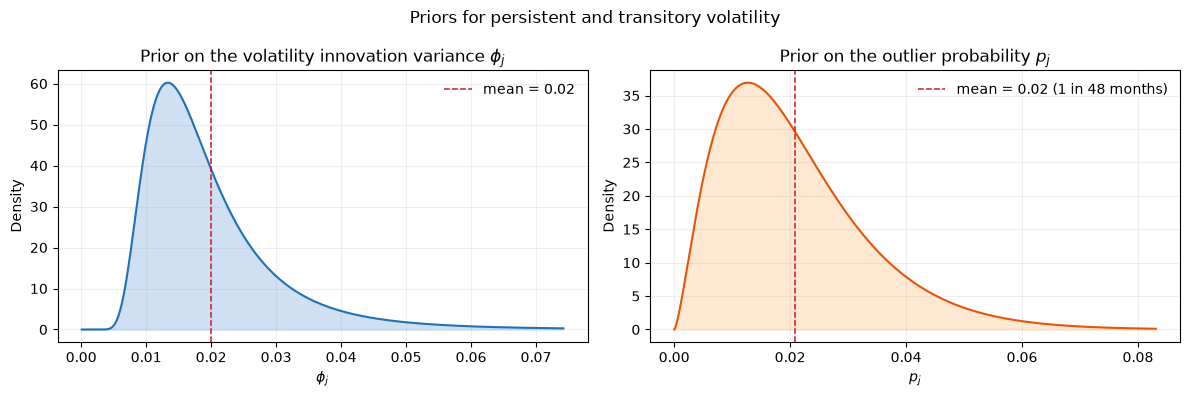

In [12]:
prior_figures = plot_minnesota_prior_by_equation(
    result["prior"], result["variables"], result["p"]
)
display(prior_figures[result["variables"][0]])

plot_phi_and_outlier_priors(result["prior"])
plt.show()

,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
state__hicp_unprocessed_food: const,0.00,0.07,4.70 × 10⁻³,4.71 × 10⁻³,1.04 × 10⁻³,2.97 × 10⁻³,3.70 × 10⁻³,5.69 × 10⁻³,6.45 × 10⁻³,2416.07
state__hicp_unprocessed_food: state__hicp_unprocessed_food L1,0.00,0.20,0.15,0.14,0.05,0.06,0.09,0.20,0.24,1691.39
state__hicp_unprocessed_food: state__hicp_unprocessed_food L2,0.00,0.10,-0.04,-0.04,0.05,-0.12,-0.09,0.01,0.05,1420.50
state__hicp_unprocessed_food: state__hicp_unprocessed_food L3,0.00,0.07,4.73 × 10⁻⁵,6.15 × 10⁻⁴,0.04,-0.07,-0.04,0.04,0.07,2448.13
state__hicp_unprocessed_food: state__hicp_unprocessed_food L4,0.00,0.05,4.07 × 10⁻⁵,-2.96 × 10⁻⁴,0.04,-0.06,-0.04,0.04,0.06,2143.38
state__hicp_unprocessed_food: state__hicp_unprocessed_food L5,0.00,0.04,-1.93 × 10⁻³,-1.87 × 10⁻³,0.03,-0.06,-0.03,0.03,0.05,2458.50
state__hicp_unprocessed_food: state__hicp_unprocessed_food L6,0.00,0.03,0.03,0.03,0.03,-0.02,1.53 × 10⁻³,0.06,0.08,2461.30
state__hicp_unprocessed_food: state__hicp_unprocessed_food L7,0.00,0.03,-6.67 × 10⁻³,-6.82 × 10⁻³,0.02,-0.05,-0.03,0.02,0.03,2752.80
state__hicp_unprocessed_food: state__hicp_unprocessed_food L8,0.00,0.03,0.01,0.01,0.02,-0.03,-0.01,0.03,0.05,2748.99
state__hicp_unprocessed_food: state__hicp_unprocessed_food L9,0.00,0.02,0.01,0.01,0.02,-0.02,-5.94 × 10⁻³,0.03,0.05,3000.00


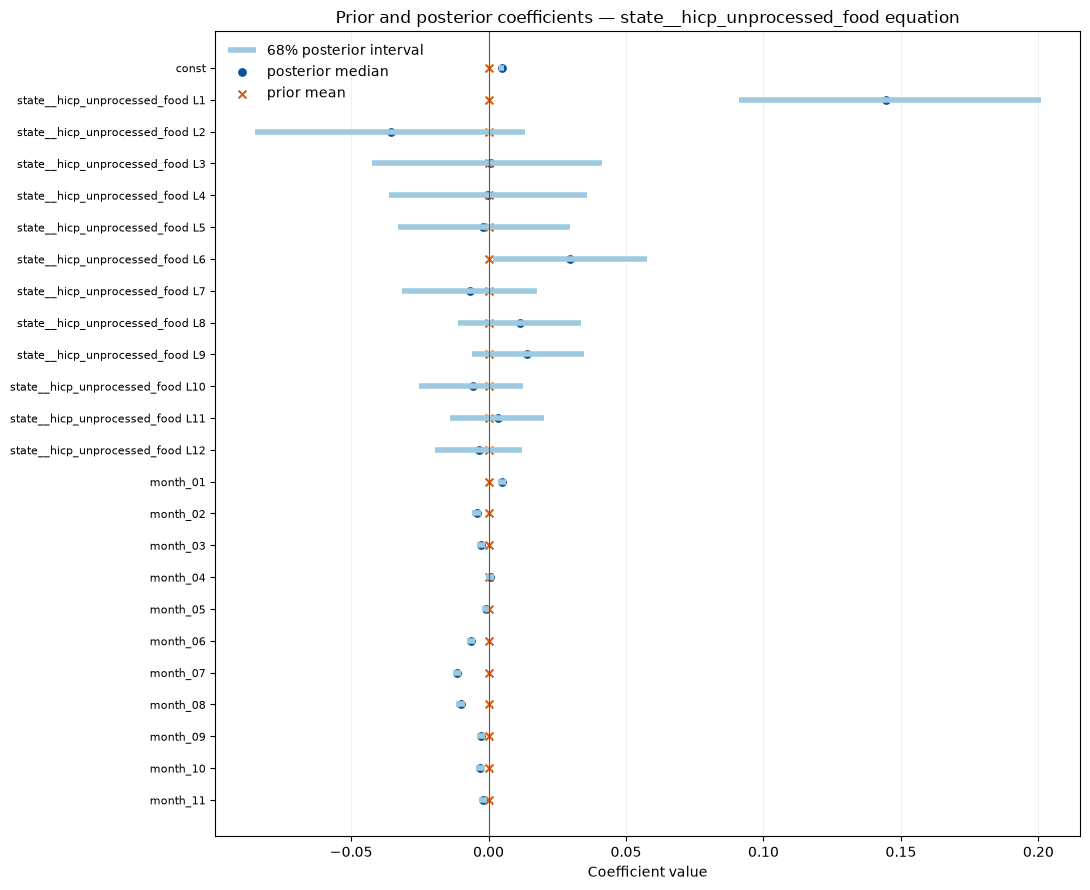

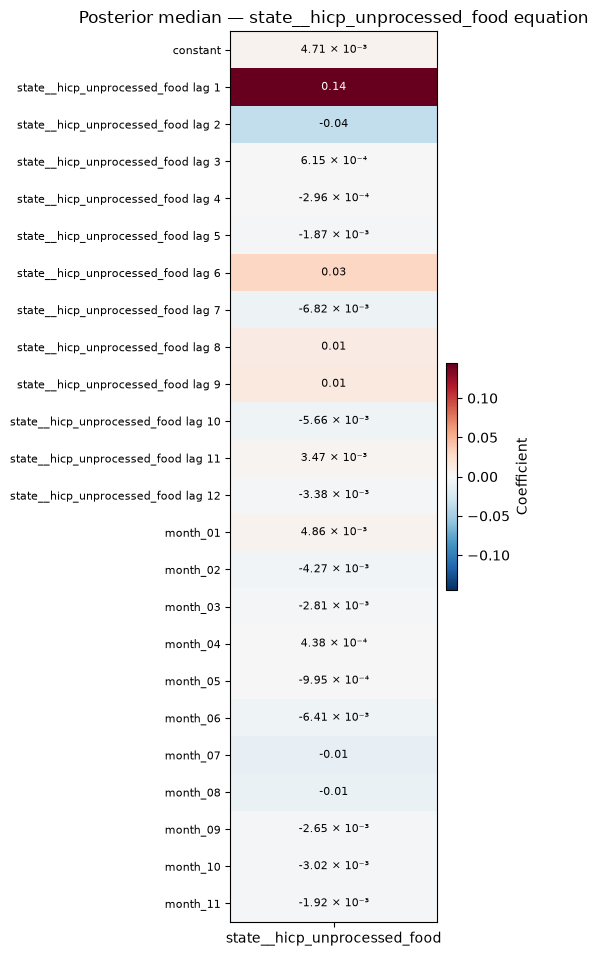

In [13]:
coef = coefficient_posterior_table(result)
display(style_numeric_table(coef, caption="Posterior coefficient summary"))

plot_shrinkage_comparison(result)
plt.show()

plot_coefficient_heatmap(result, equation=result["variables"][0])
plt.show()

## 8. Stochastic volatility, outliers and residuals

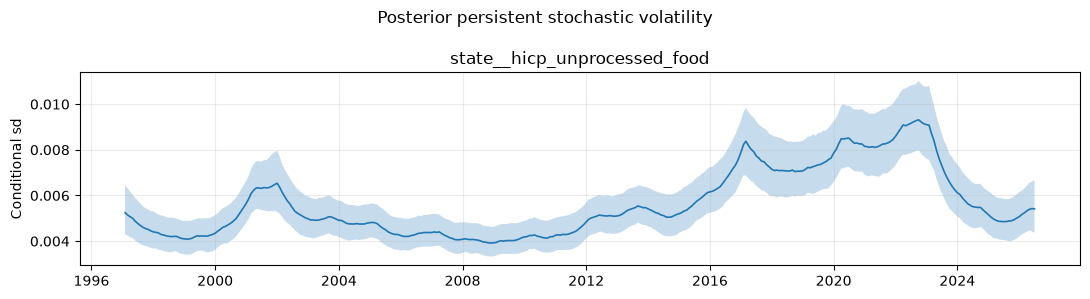

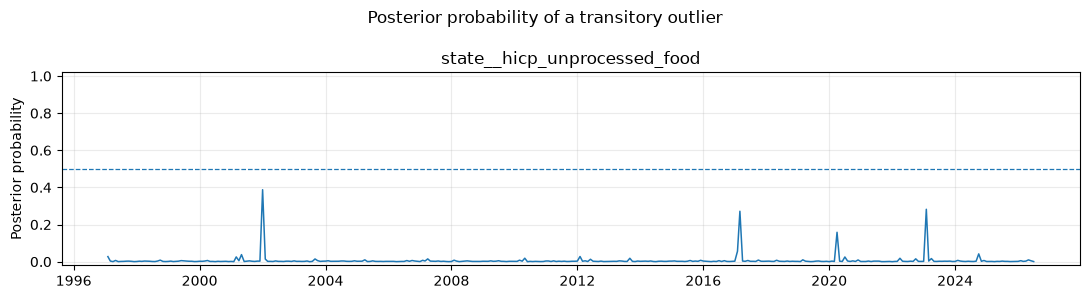

In [14]:
plot_posterior_volatility(result, include_outliers=False)
plt.show()

plot_outlier_probabilities(result)
plt.show()

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
state__hicp_unprocessed_food,0.03,0.98,0.18,0.47,0.02,3.43


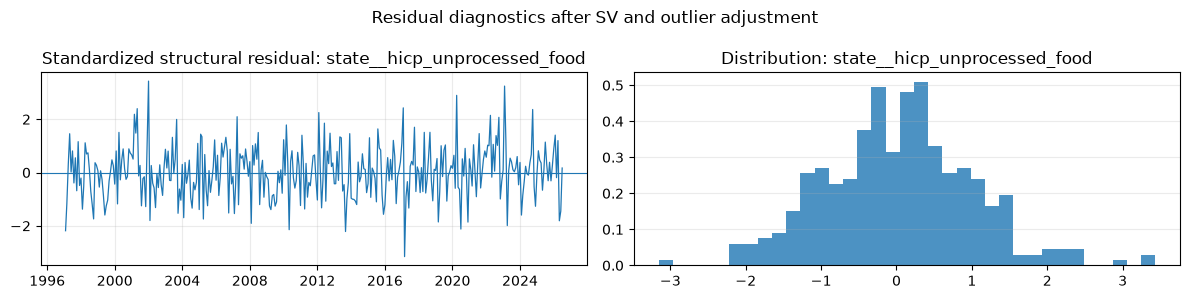

In [15]:
residual_diag = residual_diagnostic_table(result)
display(style_numeric_table(residual_diag, caption="Residual diagnostics"))

plot_standardized_residuals(result)
plt.show()

## 9. HICP nowcast and forecast

In [16]:
forecast = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=True,
    seed=2026,
)

print("Forecast contract:", forecast["forecast_contract_version"])
print("Target:", forecast["target_variable"])
print("Tail length:", forecast["tail_length"])

Forecast contract: headline-hicp-component-v1
Target: hicp_unprocessed_food
Tail length: 0


In [17]:
nowcast_level = headline_nowcast_summary_table(forecast, kind="level")
nowcast_yoy = headline_nowcast_summary_table(forecast, kind="yoy")

print("Missing target-level nowcasts:")
display(nowcast_level)
print("Corresponding YoY nowcasts:")
display(nowcast_yoy)

Missing target-level nowcasts:


,status,observed,q05,q16,median,q84,q95
date,,,,,,,


Corresponding YoY nowcasts:


,status,observed,q05,q16,median,q84,q95
date,,,,,,,


In [18]:
print("HICP index forecast horizons")
display(headline_forecast_horizon_table(forecast, kind="level"))

print("HICP YoY forecast horizons")
display(headline_forecast_horizon_table(forecast, kind="yoy"))

HICP index forecast horizons


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,101.138094,101.563237,102.127521,102.697577,103.174268
3,2026-10-01,100.682114,101.430358,102.618271,103.734216,104.637611
6,2027-01-01,101.135865,102.738899,104.457057,106.188455,107.506678
12,2027-07-01,100.101713,102.260280,104.778732,107.412616,109.834627
18,2028-01-01,99.890838,103.200023,106.663780,110.038149,113.721698


HICP YoY forecast horizons


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,1.300174,1.725999,2.291187,2.862156,3.339612
3,2026-10-01,0.411004,1.157234,2.341948,3.454888,4.355851
6,2027-01-01,-1.446243,0.115863,1.790155,3.477348,4.761916
12,2027-07-01,-2.548955,-0.447547,2.004217,4.568357,6.926233
18,2028-01-01,-2.853544,-0.501533,2.014791,4.573682,7.094490


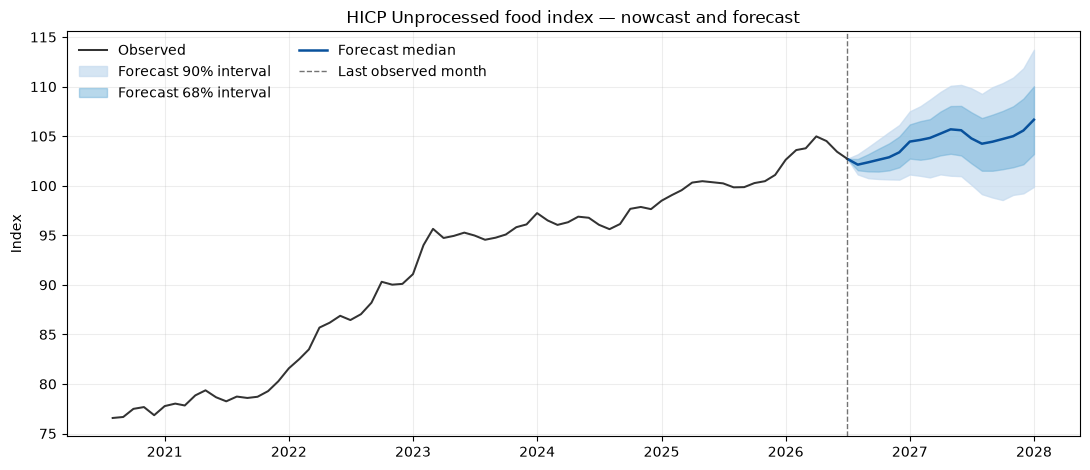

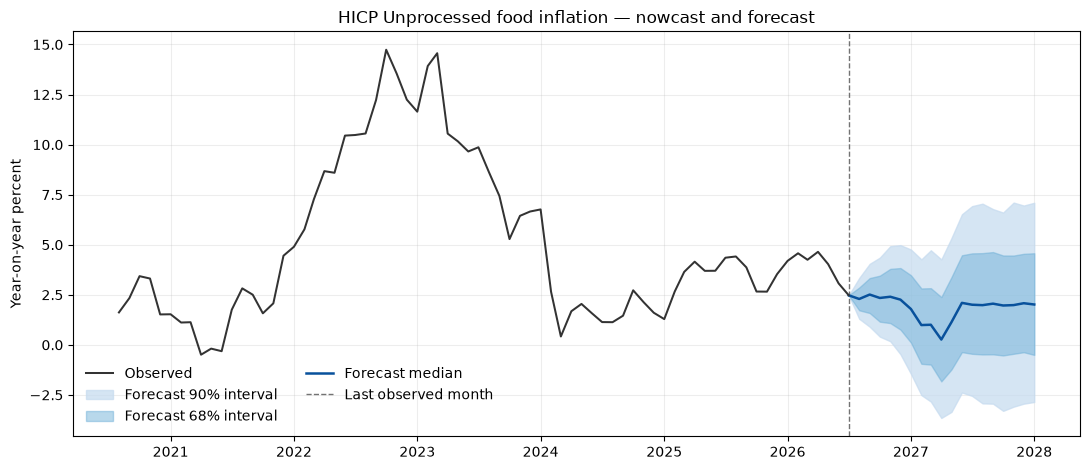

In [19]:
plot_headline_hicp_forecast_fan(forecast, kind="level", last_obs=72)
plt.show()

plot_headline_hicp_forecast_fan(forecast, kind="yoy", last_obs=72)
plt.show()

## 10. MCMC and stability diagnostics

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
log likelihood,1338.59,6.21,321.00,0.35,0.06
spectral radius,0.77,0.03,2523.39,5.64 × 10⁻⁴,0.02
phi[state__hicp_unprocessed_food],0.02,9.56 × 10⁻³,41.53,1.48 × 10⁻³,0.16
p_outlier[state__hicp_unprocessed_food],0.01,6.01 × 10⁻³,791.78,2.14 × 10⁻⁴,0.04
own L1[state__hicp_unprocessed_food],0.15,0.05,1691.39,1.34 × 10⁻³,0.02


,value
retained_draws,3000.000000
median_spectral_radius,0.771395
q95_spectral_radius,0.815276
maximum_spectral_radius,0.879963
retained_unstable_share,0.000000
B_total_proposals,6000.000000
B_unstable_proposals,0.000000
B_instability_rejection_rate,0.000000


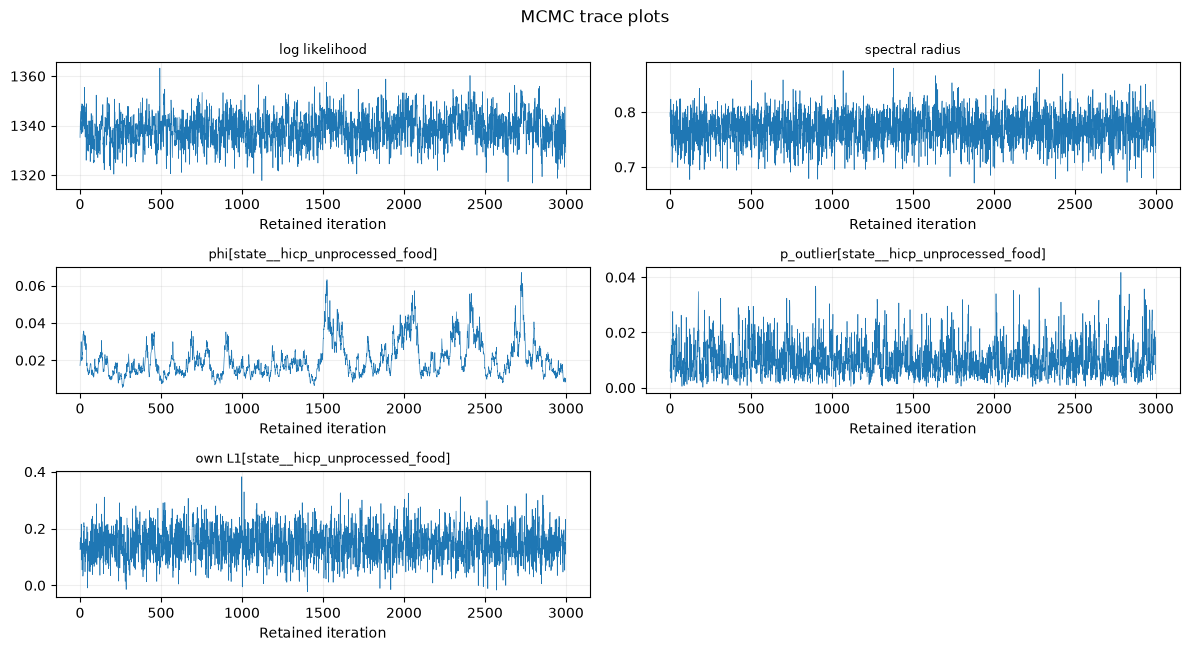

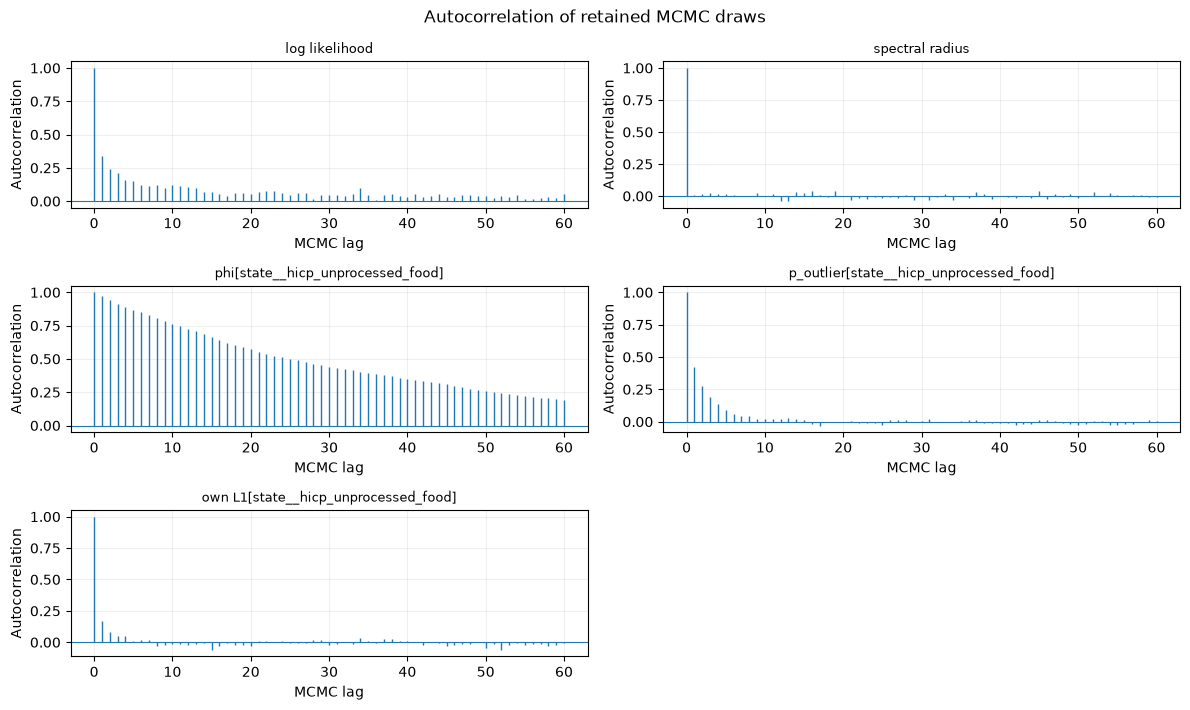

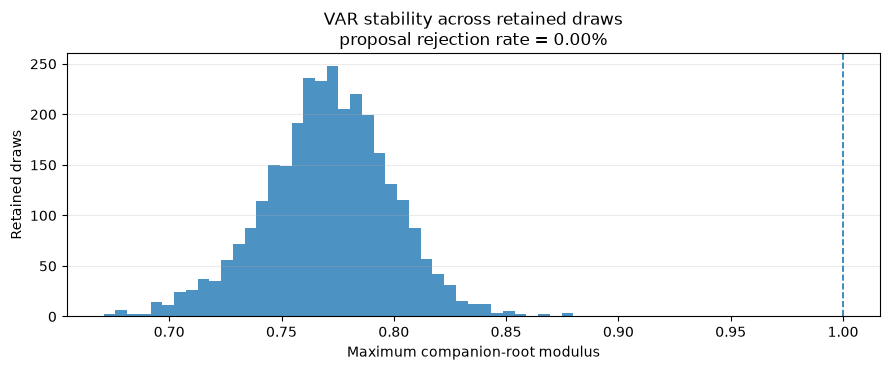

In [20]:
display(style_numeric_table(mcmc_diagnostics(result), caption="MCMC diagnostics"))
display(stability_diagnostics(result).to_frame("value"))

plot_trace_grid(result)
plt.show()

plot_chain_acf_grid(result)
plt.show()

plot_spectral_radius(result)
plt.show()

## 11. Stationarity and posterior predictive checks

In [21]:
transformed_complete = native_model_differences(native_levels, COMPONENT).dropna()
display(stationarity_tests(transformed_complete))

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
hicp_unprocessed_food,-4.207146,0.000641,17,0.242721,0.1,0,348


,observed,replicated_median,replicated_q05,replicated_q95
state__hicp_unprocessed_food: mean,2.13 × 10⁻³,1.73 × 10⁻³,6.98 × 10⁻⁴,2.70 × 10⁻³
state__hicp_unprocessed_food: sd,7.75 × 10⁻³,8.32 × 10⁻³,7.24 × 10⁻³,0.01
state__hicp_unprocessed_food: maximum_absolute,0.03,0.04,0.02,0.20


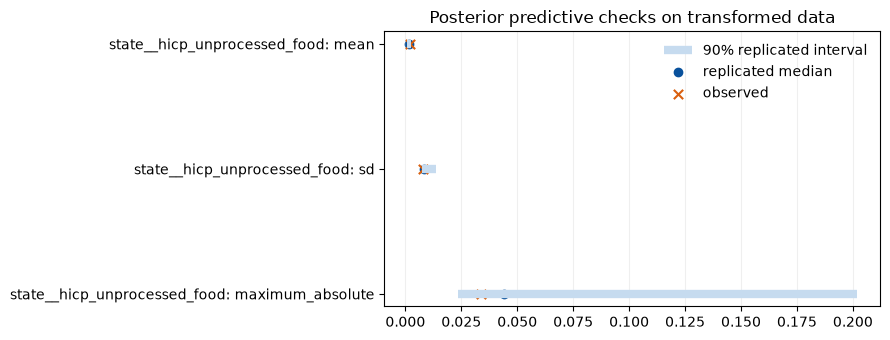

In [22]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=min(300, result["n_draws"]),
    seed=321,
)
display(style_numeric_table(ppc_summary, caption="Posterior predictive checks"))

plot_posterior_predictive_check(ppc_summary)
plt.show()

## 12. Structural interpretation

There is no multivariate structural-identification problem in this first model. With a single endogenous variable, a Cholesky or sign-restriction exercise would add labels rather than identify a distinct economic shock.

For the Headline suite, the economically important output of this model is therefore the **posterior HICP level/YoY path**, which will later be aggregated draw by draw with Processed Food and then with Energy, NEIG and Services.

## 13. Save to the common results registry

In [23]:
if SAVE_RESULTS:
    if save_energy_bvar_result is None:
        raise RuntimeError("energy_bvar_io.save_energy_bvar_result is unavailable.")
    saved = save_energy_bvar_result(result, PROJECT_ROOT / "results")
    print("Saved to:", saved["directory"])
else:
    print("SAVE_RESULTS=False — estimation is not promoted to the common registry.")

SAVE_RESULTS=False — estimation is not promoted to the common registry.


## 14. Contract for dashboard integration

The dashboard should consume the forecast object, not reproduce the model transformation. The stable fields are:

```text
hicp_level_paths
hicp_yoy_paths
future_hicp_level_paths
future_hicp_yoy_paths
path_dates
future_dates
tail_length
actual_hicp
component
component_label
target_variable
forecast_contract_version
```

This is intentionally aligned with the existing Energy HICP forecast contract. The dashboard therefore does not need special knowledge of `logdiff` versus absolute `diff`.